# Data Preparation:

In [1]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [3]:
!kaggle datasets download -d redwankarimsony/heart-disease-data

Dataset URL: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
License(s): copyright-authors
  0% 0.00/12.4k [00:00<?, ?B/s]
100% 12.4k/12.4k [00:00<00:00, 11.1MB/s]


In [4]:
! unzip "heart-disease-data.zip"

Archive:  heart-disease-data.zip
  inflating: heart_disease_uci.csv   


# Exploratory Data Analysis (EDA)

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data=pd.read_csv("heart_disease_uci.csv")

In [7]:
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 531 entries, 0 to 912
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        531 non-null    int64  
 1   age       531 non-null    int64  
 2   sex       531 non-null    object 
 3   dataset   531 non-null    object 
 4   cp        531 non-null    object 
 5   trestbps  531 non-null    float64
 6   chol      531 non-null    float64
 7   fbs       531 non-null    object 
 8   restecg   531 non-null    object 
 9   thalch    531 non-null    float64
 10  exang     531 non-null    object 
 11  oldpeak   531 non-null    float64
 12  slope     531 non-null    object 
 13  num       531 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 62.2+ KB


In [19]:
# I will convert to % for better understading of missing data relevance
data.isnull().sum()*100/len(data)

,0
id,0.0
age,0.0
sex,0.0
dataset,0.0
cp,0.0
trestbps,0.0
chol,0.0
fbs,0.0
restecg,0.0
thalch,0.0


In [13]:
data.drop(['ca', 'thal'], axis=1, inplace=True)

In [17]:
data.dropna(inplace=True)

In [21]:
#Converting data for more comfortable use
data['num'] = data['num'].map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})

# Model Training:

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [29]:
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
      data[col] = le.fit_transform(data[col])

In [31]:
x_train, x_test, y_train, y_test = train_test_split(data.drop('num', axis=1), data['num'], test_size=0.2, random_state=42)

In [33]:
model=LogisticRegression()
model.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Model Evaluation:

Accuracy: 0.8037383177570093

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.64      0.75        50
           1       0.75      0.95      0.84        57

    accuracy                           0.80       107
   macro avg       0.83      0.79      0.80       107
weighted avg       0.83      0.80      0.80       107


Confusion Matrix:
 [[32 18]
 [ 3 54]]


<Axes: >

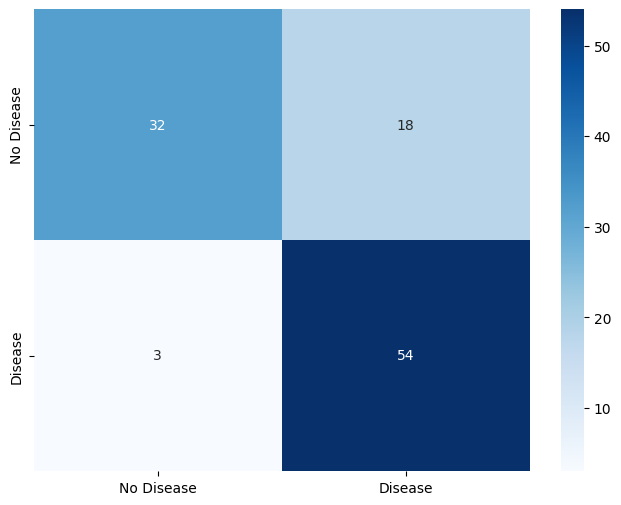

In [38]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])